In [1]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import csv
import os

sns.set_style("darkgrid")

KeyboardInterrupt: 

In [2]:
src_dir = '../../data/probing_results/'

In [5]:
model_name = os.listdir(src_dir)[0]
model_name

'bert_base_42_train_1_orig'

In [6]:
def score_model(src_path):
    predictions, labels = [], []
    with open(src_path, 'r') as src_file:
        csv_reader = csv.reader(src_file, delimiter='\t')
        for row in csv_reader:
            predictions.append(row[0])
            labels.append(row[1])
        s = spearmanr(predictions, labels)
    return s.statistic if s.pvalue < 0.05 else None

In [7]:
def add_to_res_dict(res_dict, model, checkpoint, feature, layer, score):
    res_dict['model'].append(model)
    res_dict['checkpoint'].append(checkpoint)
    res_dict['feature'].append(feature)
    res_dict['layer'].append(layer)
    res_dict['score'].append(score)

In [8]:
res_dict = {'model': [], 'checkpoint':[], 'feature': [], 'layer':[], 'score':[]}

model_dir = os.path.join(src_dir, model_name)
for checkpoint_dir_name in os.listdir(model_dir):
    checkpoint_num = int(checkpoint_dir_name.split('-')[-1])
    checkpoint_dir = os.path.join(model_dir, checkpoint_dir_name)
    try:
        for layer in os.listdir(checkpoint_dir):
            layer_dir = os.path.join(checkpoint_dir, layer)
            for feature_file_name in os.listdir(layer_dir):
                feature = feature_file_name[:-4]
                feature_file_path = os.path.join(layer_dir, feature_file_name)
                score = score_model(feature_file_path)
                add_to_res_dict(res_dict, model_name, checkpoint_num, feature, int(layer)+1, score)
    except:
        print(checkpoint_dir)

In [11]:
res_df = pd.DataFrame.from_dict(res_dict)

In [12]:
for model in list(res_df['model'].unique()):
    model_df = res_df[res_df['model'] == model]
    vmin = model_df['score'].min()
    vmax = model_df['score'].max()

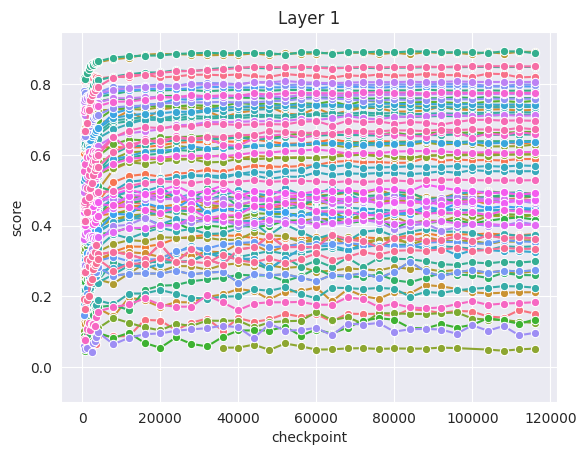

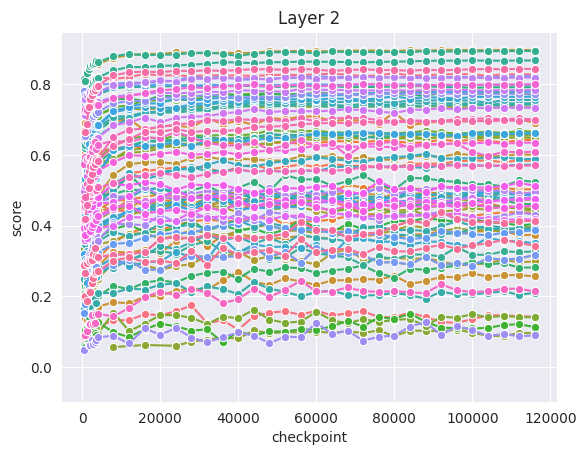

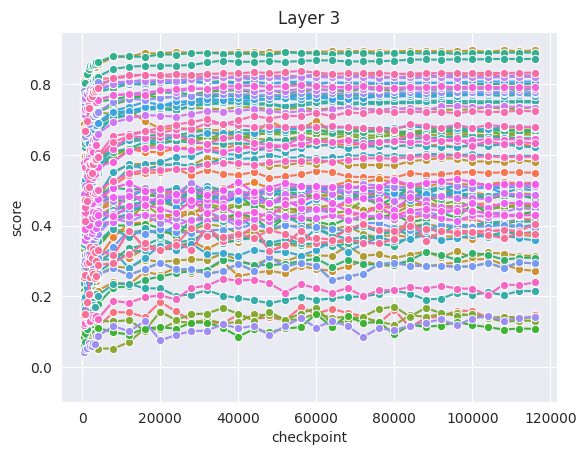

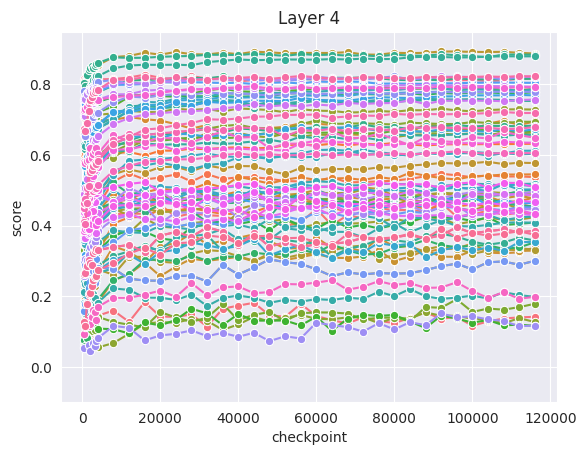

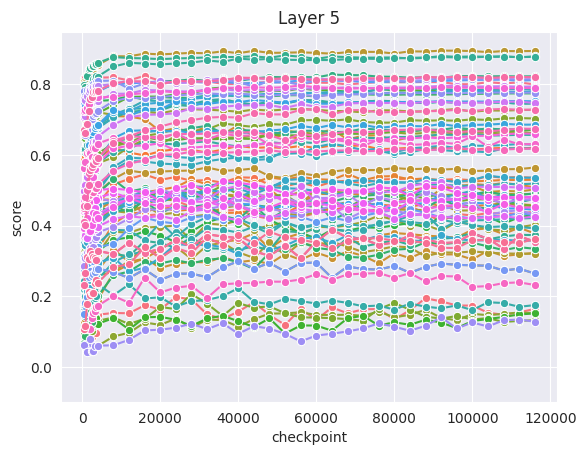

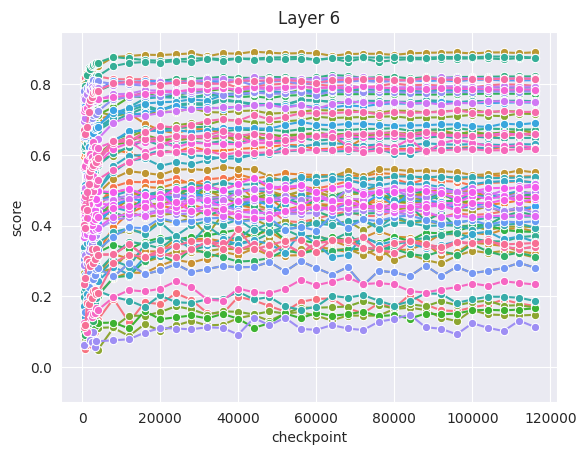

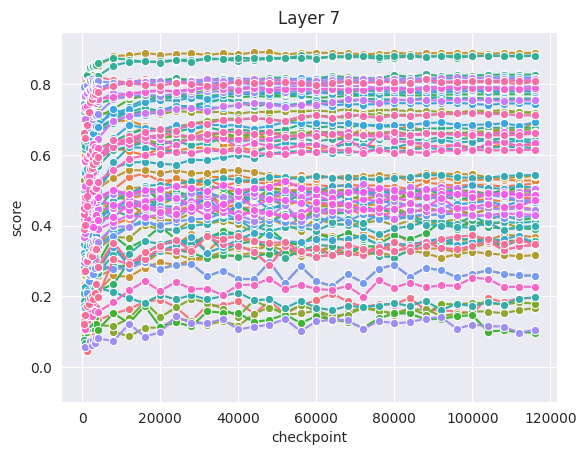

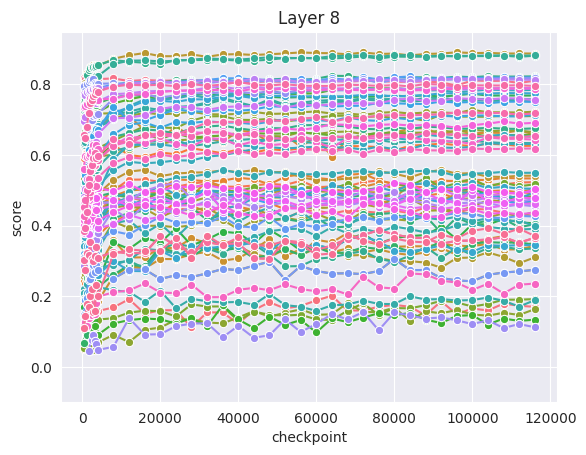

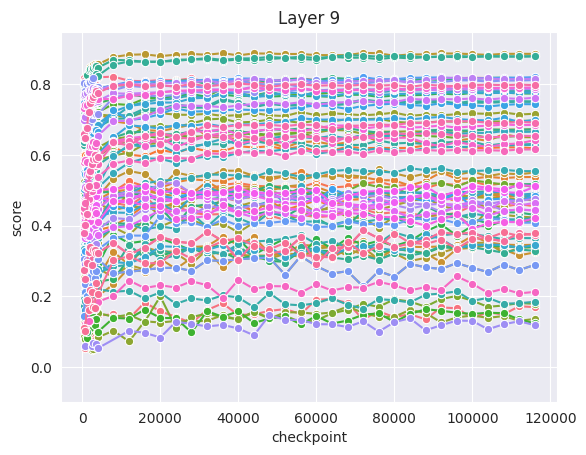

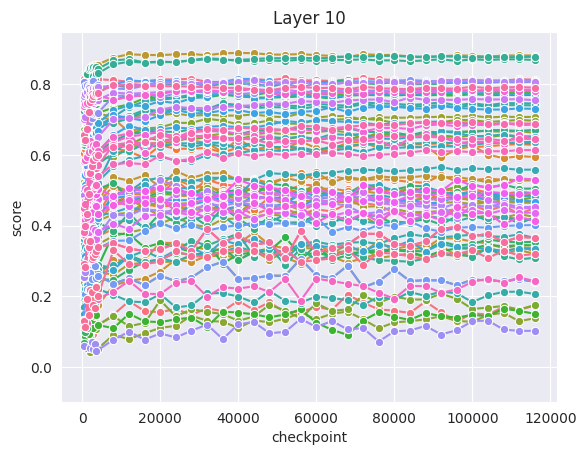

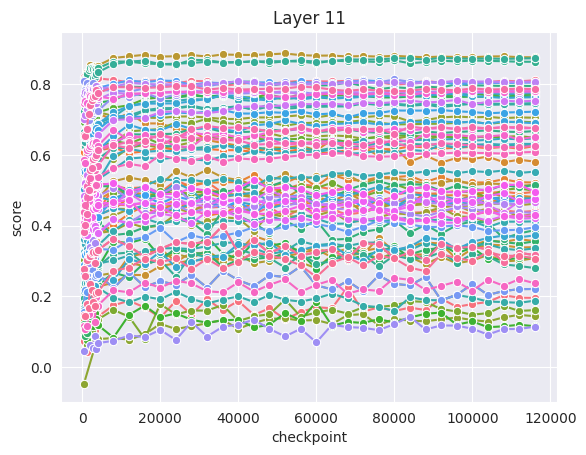

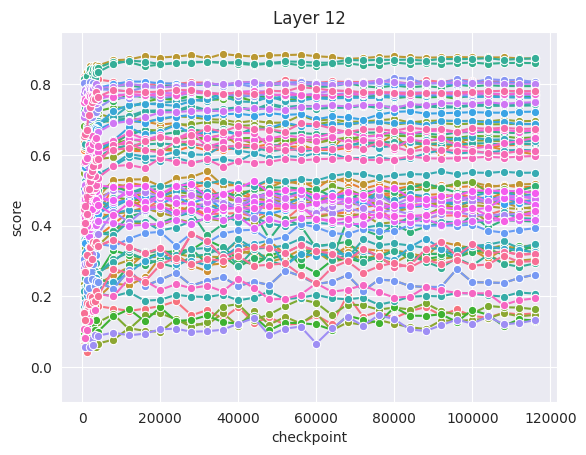

In [15]:
for layer in sorted(list(model_df['layer'].unique())):
    layer_df = model_df[model_df['layer'] == layer]
    
    plt.figure()
    lineplot = sns.lineplot(data=layer_df, x='checkpoint', y='score', hue='feature', marker='o', legend=False)
    plt.ylim(vmin-0.05, vmax+0.05)
    plt.title(f'Layer {layer}')
    plt.show()

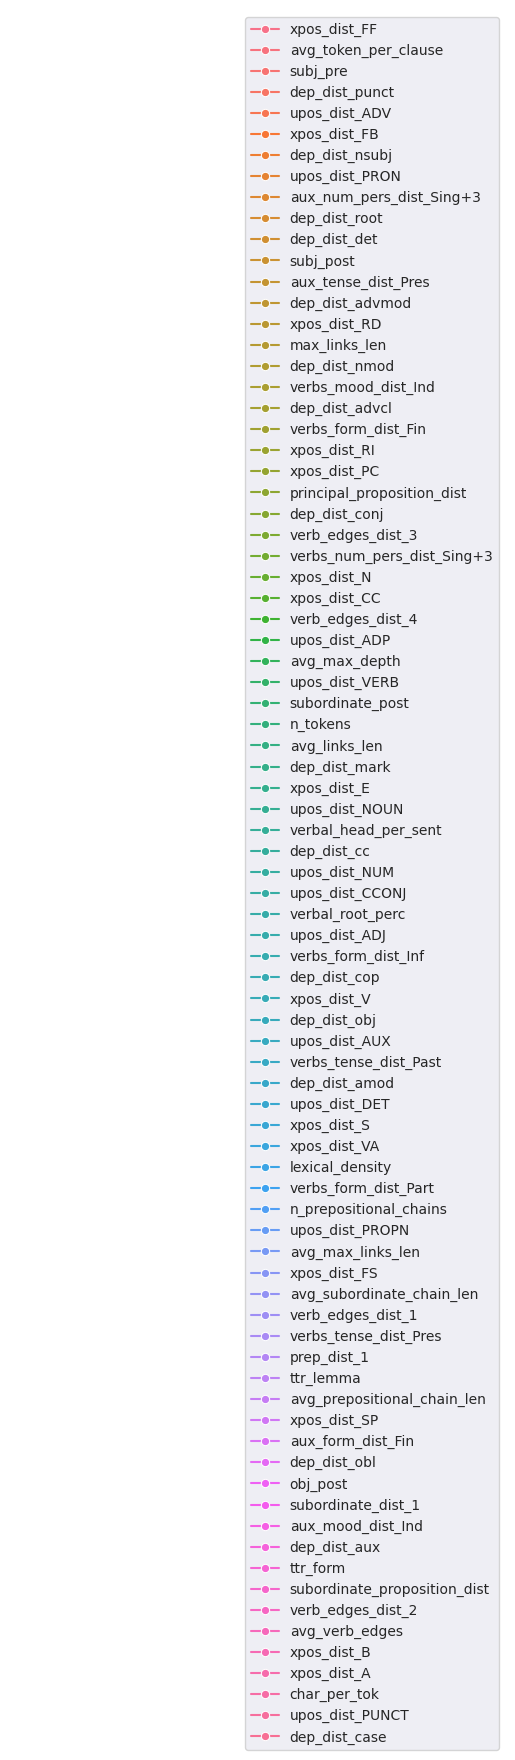

In [18]:
legend_plot = sns.lineplot(data=model_df, x='checkpoint', y='score', hue='feature', marker='o')
handles, labels = legend_plot.get_legend_handles_labels()

# Close the dummy plot to avoid displaying it
plt.close()

# Create a new figure for the legend only
plt.figure()

# Add only the legend to this figure
plt.legend(handles=handles, labels=labels)#, loc='center', frameon=False)
plt.axis('off')  # Turn off the axis to only show the legend

plt.show()